SRSK

## Import Libraries

In [ ]:
pip install spectral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 8.8 MB/s eta 0:00:00


In [ ]:
import spectral
import spectral.io.envi as envi

import skimage as ski
from skimage.transform import rotate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

## Data Loading

In [ ]:
species = 'Bread Wheat'
variety = 'RAJ3765_K_22'    # Same as folder name
filename = 'B2.bil'
basepath = '/content/drive/MyDrive/1. MTP-I/wheat_bulk_50_var/'
bil_file_path = basepath+species+'/'+variety+'/'+filename
hdr_file_path = bil_file_path+'.hdr'

print(bil_file_path)
print(hdr_file_path)

/content/drive/MyDrive/1. MTP-I/wheat_bulk_50_var/Bread Wheat/RAJ3765_K_22/B2.bil
/content/drive/MyDrive/1. MTP-I/wheat_bulk_50_var/Bread Wheat/RAJ3765_K_22/B2.bil.hdr


	Data Source:   '/content/drive/MyDrive/1. MTP-I/wheat_bulk_50_var/Bread Wheat/RAJ3765_K_22/B2.bil'
	# Rows:            850
	# Samples:         320
	# Bands:           168
	Interleave:        BIL
	Quantization:  32 bits
	Data format:   float32


ImageView object:
  Display bands       :  [0, 84, 167]
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(0.0), np.float64(0.633404016494751)]
    G: [np.float64(0.05978821590542793), np.float64(0.7987759113311768)]
    B: [np.float64(0.011601953767240047), np.float64(0.5298580527305603)]

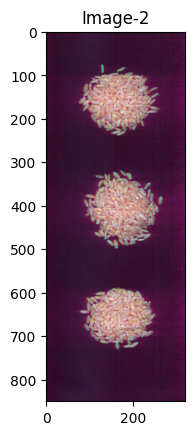

In [ ]:
#bil_file_path = '/content/drive/MyDrive/1. MTP-I/wheat_bulk_50_var/Bread Wheat /HD_2733_K_22/B1.bil'
#hdr_file_path = '/content/drive/MyDrive/1. MTP-I/wheat_bulk_50_var/Bread Wheat /HD_2733_K_22/B1.bil.hdr'

himg = envi.open(hdr_file_path, bil_file_path)
print(himg)
spectral.imshow(himg, title='Image-2', )

In [ ]:
print(himg.shape)
print(type(himg))

(850, 320, 168)
<class 'spectral.io.bilfile.BilFile'>


In [ ]:
# # Visualizing Band 51

# band = 50
# plt.imshow(himg[:,:,band], cmap = 'gray')
# plt.title(f'Band No. {band+1}')

In [ ]:
# Checking the bands for removal

# band = 13
# plt.imshow(himg[:,:,band], cmap = 'gray')
# plt.title(f'Band No. {band+1}')

In [ ]:

# himg[:,:,50]

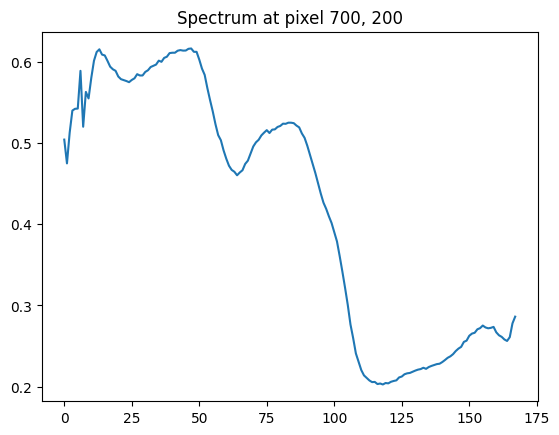

In [ ]:
pixel = himg[400, 150]
plt.plot(pixel)
plt.title('Spectrum at pixel 700, 200')
plt.show()

## Segmentation

(850, 320, 168)
(850, 320, 147)


ImageView object:
  Display bands       :  [0, 73.5, 146]
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(0.06745920330286026), np.float64(0.8405102491378784)]
    G: [np.float64(0.06022929027676582), np.float64(0.7946268320083618)]
    B: [np.float64(0.05224421247839928), np.float64(0.5715645551681519)]

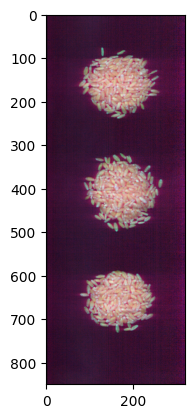

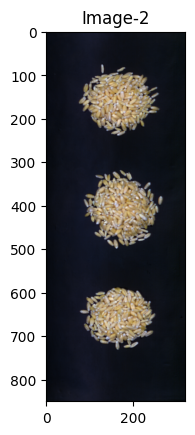

In [ ]:
# Removing first 14 bands and last 7 bands of the HSI image (21 bands)
# Original Bands = 0 to 167

print(himg.shape)
spectral.imshow(himg)
himg = himg[:, :, 14:161]
print(himg.shape)

spectral.imshow(himg, title='Image-2')

Text(0.5, 1.0, 'Band No. 60')

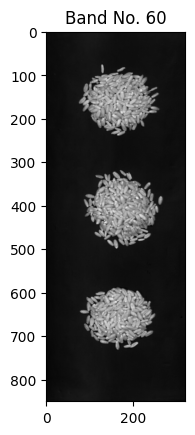

In [ ]:
# Selecting Band 60 for binary conversion

band60 = himg[:,:,59]
plt.imshow(band60, cmap='gray')
plt.title(f'Band No. 60')

0.29416895


Text(0.5, 1.0, 'Binary Image')

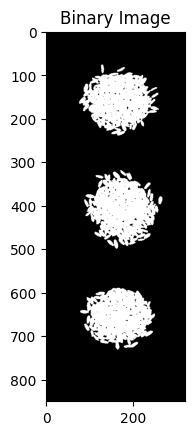

In [ ]:
# Finding Otsu threshold

threshold = ski.filters.threshold_otsu(band60)
print(threshold)

# Getting binary image based on above threshold

bimg = band60 >= threshold
plt.imshow(bimg, cmap='gray')
plt.title('Binary Image')
#plt.xticks(np.arange(100, 320, step=50))
#plt.grid()

In [ ]:
# Multiply the binary mask

# bands = []

# for i in range(10, 162):
#   bands.append(np.multiply(bimg, himg[:,:,i]))

# plt.imshow(bands[150], cmap='gray')

(850, 320)
(850, 320)


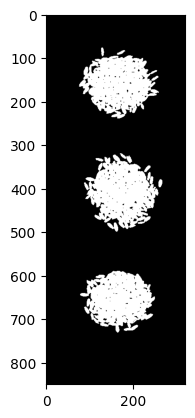

In [ ]:
# Rmoving the third dimension of the binary image

print(bimg.shape)
bimg1 = bimg.squeeze()
print(bimg1.shape)
plt.imshow(bimg1, cmap = 'gray')

<ipython-input-30-974b26de3a17>:6: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  closed_image = closing(bimg1, square(5))  # Adjust the size as needed


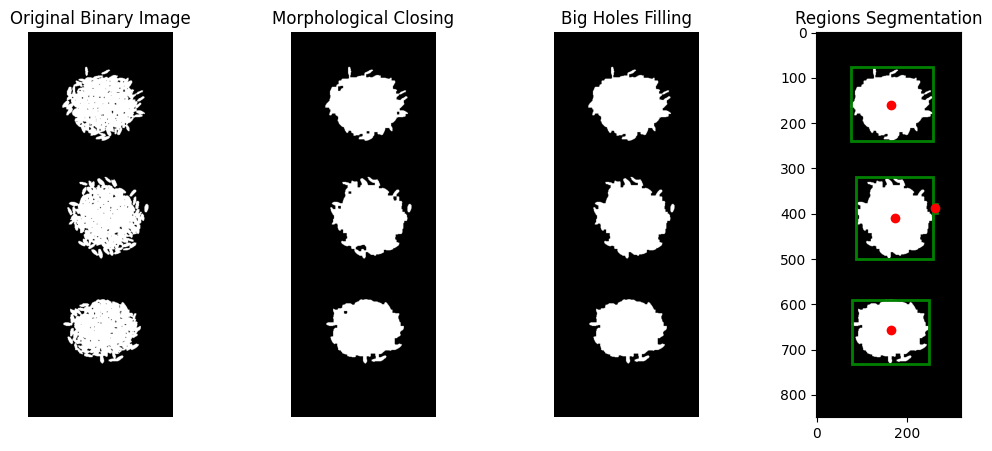

In [ ]:
from scipy.ndimage import binary_fill_holes
from skimage.morphology import closing, square
from skimage.measure import label, regionprops

# Apply morphological closing to close larger holes
closed_image = closing(bimg1, square(5))  # Adjust the size as needed

# Fill holes in the closed image
filled_image = binary_fill_holes(closed_image)

# Label the filled regions
labeled_image = label(filled_image)

# Find the properties of the labeled regions
regions = regionprops(labeled_image)

# Display the original, closed, and filled images
fig, axes = plt.subplots(1, 4, figsize=(13, 5))
axes[0].imshow(bimg1, cmap='gray')
axes[0].set_title('Original Binary Image')
axes[0].axis('off')

axes[1].imshow(closed_image, cmap='gray')
axes[1].set_title('Morphological Closing')
axes[1].axis('off')

axes[2].imshow(filled_image, cmap='gray')
axes[2].set_title('Big Holes Filling')
axes[2].axis('off')

axes[3].imshow(filled_image, cmap='gray')
axes[3].set_title('Regions Segmentation')

# Plot the centers of the regions
for region in regions:
    y, x = region.centroid
    axes[3].plot(x, y, 'ro')  # red dots for centers

    # Plot bounding box
    minr, minc, maxr, maxc = region.bbox
    rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minr,
                         fill=False, edgecolor='green', linewidth=2)
    axes[3].add_patch(rect)

plt.show()


In [ ]:
# Extract properties and store in a DataFrame

region_data = []
for region in regions:
    region_data.append({
        'label': region.label,
        'centroid_x': region.centroid[0],
        'centroid_y': region.centroid[1],
        'min_row': region.bbox[0],
        'min_col': region.bbox[1],
        'max_row': region.bbox[2],
        'max_col': region.bbox[3],
        'area': region.area,

        'height': region.bbox[2] - region.bbox[0],
        'width': region.bbox[3] - region.bbox[1]
    })

df = pd.DataFrame(region_data)
df

,label,centroid_x,centroid_y,min_row,min_col,max_row,max_col,area,height,width
0,1,160.069487,165.062662,77,75,240,258,17730.0,163,183
1,2,410.129980,172.992042,320,87,500,257,19603.0,180,170
2,3,388.189394,260.810606,379,257,398,266,132.0,19,9
3,4,656.062690,165.055559,590,78,732,249,16127.0,142,171


In [ ]:
# Drop unwanted rows

indices_to_remove = []

for i in list(df.index):
    if df['height'][i]<50:
        indices_to_remove.append(i)

df = df.drop(index=indices_to_remove)
df = df.reset_index(drop=True)
df

,label,centroid_x,centroid_y,min_row,min_col,max_row,max_col,area,height,width
0,1,160.069487,165.062662,77,75,240,258,17730.0,163,183
1,2,410.129980,172.992042,320,87,500,257,19603.0,180,170
2,4,656.062690,165.055559,590,78,732,249,16127.0,142,171


In [ ]:
# # Removing first 14 bands and last 7 bands of the HSI image (21 bands)
# # Original Bands = 0 to 167

# print(himg.shape)
# spectral.imshow(himg)
# himg = himg[:, :, 14:161]
# print(himg.shape)

# spectral.imshow(himg, title='After Noisy Bands Removal')

In [ ]:
print(himg.shape)

(850, 320, 147)


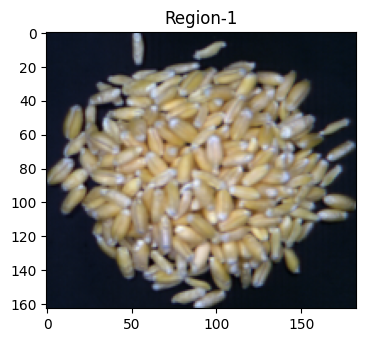

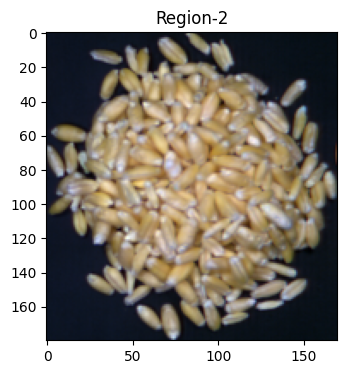

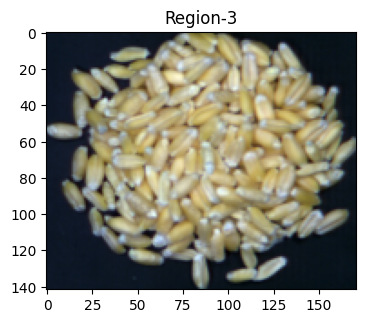

In [ ]:
# Visualizing each region

n = len(list(df.index))

for i in range(n):
  minr, minc, maxr, maxc = df['min_row'][i], df['min_col'][i], df['max_row'][i], df['max_col'][i]
  minr, minc, maxr, maxc = int(minr), int(minc), int(maxr), int(maxc)
  spectral.imshow(himg[minr:maxr, minc:maxc], figsize = (4, 4), title = f'Region-{i+1}')

## Selecting Region and Making Patches

In [ ]:
region = 0

ImageView object:
  Display bands       :  [0, 73.5, 146]
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(0.16942352056503296), np.float64(0.8405102491378784)]
    G: [np.float64(0.09508396685123444), np.float64(0.7778781056404114)]
    B: [np.float64(0.08003168553113937), np.float64(0.5409162044525146)]

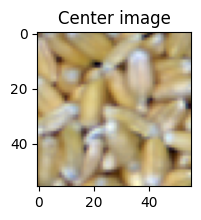

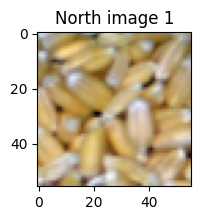

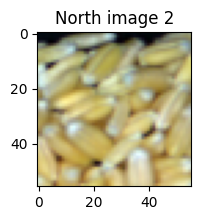

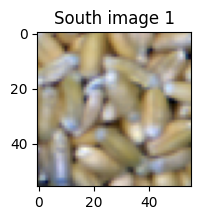

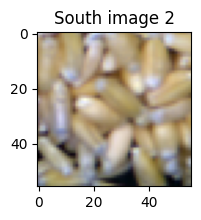

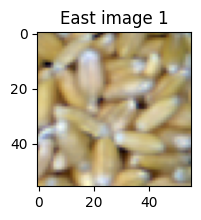

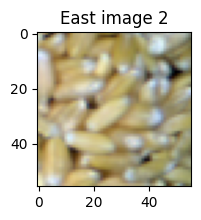

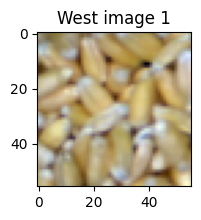

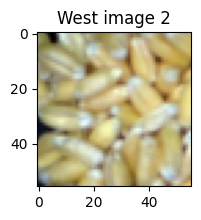

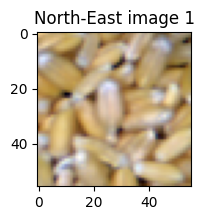

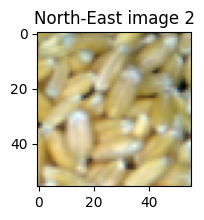

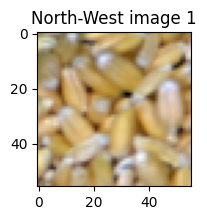

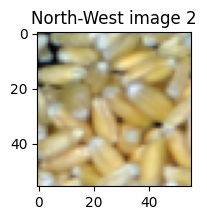

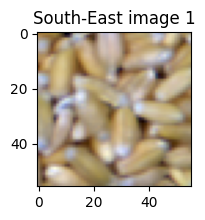

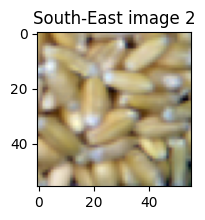

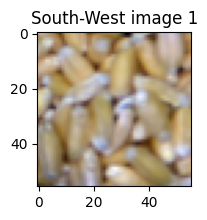

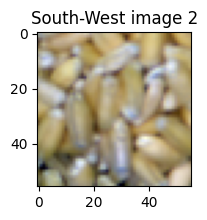

In [ ]:
# Lets explore region

a = df['centroid_x'][region]
b = df['centroid_y'][region]
a, b = int(a), int(b)

h0 = himg[a-28:a+28, b-28:b+28]

shift1 = 18
# Shift by 18 in NEWS directions
h1 = himg[a-28-shift1:a+28-shift1, b-28:b+28]       # North (-18)
h2 = himg[a-28-2*shift1:a+28-2*shift1, b-28:b+28]
h3 = himg[a-28+shift1:a+28+shift1, b-28:b+28]       # South (+18)
h4 = himg[a-28+2*shift1:a+28+2*shift1, b-28:b+28]

h5 = himg[a-28:a+28, b-28+shift1:b+28+shift1]       # East (+18)
h6 = himg[a-28:a+28, b-28+2*shift1:b+28+2*shift1]
h7 = himg[a-28:a+28, b-28-shift1:b+28-shift1]       # West (-18)
h8 = himg[a-28:a+28, b-28-2*shift1:b+28-2*shift1]

shift2 = 11
# Shift by 11 in Diagonal Direction
h9 = himg[a-28-shift2:a+28-shift2, b-28+shift2:b+28+shift2] # North-East (-11,+11)
h10 = himg[a-28-2*shift2:a+28-2*shift2, b-28+2*shift2:b+28+2*shift2]
h11 = himg[a-28-shift2:a+28-shift2, b-28-shift2:b+28-shift2] # North-West (-11,-11)
h12 = himg[a-28-2*shift2:a+28-2*shift2, b-28-2*shift2:b+28-2*shift2]

h13 = himg[a-28+shift2:a+28+shift2, b-28+shift2:b+28+shift2] # South-East (+11, +11)
h14 = himg[a-28+2*shift2:a+28+2*shift2, b-28+2*shift2:b+28+2*shift2]
h15 = himg[a-28+shift2:a+28+shift2, b-28-shift2:b+28-shift2] # South-West (+11, -11)
h16 = himg[a-28+2*shift2:a+28+2*shift2, b-28-2*shift2:b+28-2*shift2]


spectral.imshow(h0, figsize = (2, 2), title = 'Center image')
spectral.imshow(h1, figsize = (2, 2), title = 'North image 1')
spectral.imshow(h2, figsize = (2, 2), title = 'North image 2')
spectral.imshow(h3, figsize = (2, 2), title = 'South image 1')
spectral.imshow(h4, figsize = (2, 2), title = 'South image 2')

spectral.imshow(h5, figsize = (2, 2), title = 'East image 1')
spectral.imshow(h6, figsize = (2, 2), title = 'East image 2')
spectral.imshow(h7, figsize = (2, 2), title = 'West image 1')
spectral.imshow(h8, figsize = (2, 2), title = 'West image 2')

spectral.imshow(h9, figsize = (2, 2), title = 'North-East image 1')
spectral.imshow(h10, figsize = (2, 2), title = 'North-East image 2')
spectral.imshow(h11, figsize = (2, 2), title = 'North-West image 1')
spectral.imshow(h12, figsize = (2, 2), title = 'North-West image 2')

spectral.imshow(h13, figsize = (2, 2), title = 'South-East image 1')
spectral.imshow(h14, figsize = (2, 2), title = 'South-East image 2')
spectral.imshow(h15, figsize = (2, 2), title = 'South-West image 1')
spectral.imshow(h16, figsize = (2, 2), title = 'South-West image 2')


In [ ]:
# Checking the shape of all 17 images

print("True" if h0.shape==(56, 56, 147) else "C")
print("True" if h1.shape==(56, 56, 147) else "N1")
print("True" if h2.shape==(56, 56, 147) else "N2")
print("True" if h3.shape==(56, 56, 147) else "S1")
print("True" if h4.shape==(56, 56, 147) else "S2")
print("True" if h5.shape==(56, 56, 147) else "E1")
print("True" if h6.shape==(56, 56, 147) else "E2")
print("True" if h7.shape==(56, 56, 147) else "W1")
print("True" if h8.shape==(56, 56, 147) else "W2")
print("True" if h9.shape==(56, 56, 147) else "NE1")
print("True" if h10.shape==(56, 56, 147) else "NE2")
print("True" if h11.shape==(56, 56, 147) else "NW1")
print("True" if h12.shape==(56, 56, 147) else "NW2")
print("True" if h13.shape==(56, 56, 147) else "SE1")
print("True" if h14.shape==(56, 56, 147) else "SE2")
print("True" if h15.shape==(56, 56, 147) else "SW1")
print("True" if h16.shape==(56, 56, 147) else "SW2")

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [ ]:
himgs = [h0, h1, h2, h3, h4, h5, h6, h7, h8, h9,
         h10, h11, h12, h13, h14, h15, h16]

In [ ]:
# Saving hyperspectral images

folder_name = variety

if region==0 or region==1:
    purpose = 'tr'
    print("Saved in Train Folder")
elif filename=='B1.bil':
    purpose = 'va'
    print("Saved in Validation Folder")
elif filename=='B2.bil':
    purpose = 'te'
    print("Saved in Test Folder")


def create_folder_if_not_exists(folder_path):
    # Check if the folder exists
    if not os.path.exists(folder_path):
        # If it doesn't exist, create it
        os.makedirs(folder_path)
        print(f"Folder created at: {folder_path}")
    else:
        print(f"Folder already exists at: {folder_path}")


if purpose == 'tr':
    save_path = '/content/drive/MyDrive/1. MTP-I/Dataset_50_Varieties/Train/' + folder_name
    create_folder_if_not_exists(save_path)
    if filename=='B1.bil': count = 1 + region*85
    elif filename=='B2.bil': count = 1 + (region+2)*85
elif purpose == 'te':
    save_path = '/content/drive/MyDrive/1. MTP-I/Dataset_50_Varieties/Test/' + folder_name
    create_folder_if_not_exists(save_path)
    count = 1
elif purpose == 'va':
    save_path = '/content/drive/MyDrive/1. MTP-I/Dataset_50_Varieties/Validation/' + folder_name
    create_folder_if_not_exists(save_path)
    count = 1

for i, img in enumerate(himgs):
    file_name = f"{count}.hdr"
    file_path = os.path.join(save_path, file_name)
    envi.save_image(file_path, img, dtype=np.float32, interleave = 'bil')
    count += 1

Saved in Validation Folder
Folder created at: /content/drive/MyDrive/1. MTP-I/Dataset_50_Varieties/Validation/DBW187_K_22


## Data Augmentation

ImageView object:
  Display bands       :  [0, 73.5, 146]
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(0.22614197432994843), np.float64(0.8146762251853943)]
    G: [np.float64(0.15903018414974213), np.float64(0.7305389642715454)]
    B: [np.float64(0.09528195112943649), np.float64(0.5344089865684509)]

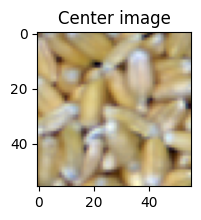

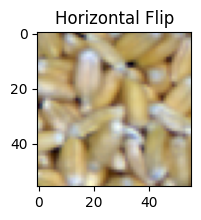

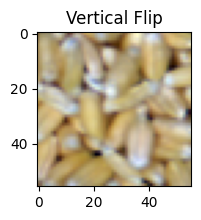

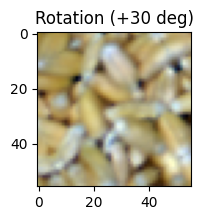

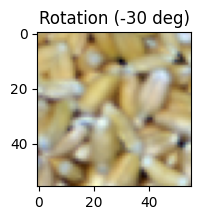

In [ ]:
h = h0

hf = np.flip(h, axis=1)

# Vertical flip
vf = np.flip(h, axis=0)

# Rotation
rotation_angle = 30     # Anticlockwise
ra = rotate(h, angle = rotation_angle, mode='reflect', preserve_range=True)   # Anticlockwise
rc = rotate(h, angle = -rotation_angle, mode='reflect', preserve_range=True)  # Clockwise

spectral.imshow(h0, figsize = (2, 2), title = 'Center image')
spectral.imshow(hf, figsize = (2, 2), title = 'Horizontal Flip')
spectral.imshow(vf, figsize = (2, 2), title = 'Vertical Flip')
spectral.imshow(ra, figsize = (2, 2), title = 'Rotation (+30 deg)')
spectral.imshow(rc, figsize = (2, 2), title = 'Rotation (-30 deg)')

In [ ]:
for h in himgs:
    # Horizontal flip
    hf = np.flip(h, axis=1)

    # Vertical flip
    vf = np.flip(h, axis=0)

    # Rotation
    rotation_angle = 30     # Anticlockwise
    ra = rotate(h, angle = rotation_angle, mode='reflect', preserve_range=True)   # Anticlockwise
    rc = rotate(h, angle = -rotation_angle, mode='reflect', preserve_range=True)  # Clockwise

    haug = [hf, vf, ra, rc]
    for i, img in enumerate(haug):
        file_name = f"{count}.hdr"
        file_path = os.path.join(save_path, file_name)
        envi.save_image(file_path, img, dtype=np.float32, interleave = 'bil')
        count += 1


Thank You!